# Car Price Prediction with Machine Learning

## OASIS INFOBYTE Data Science Internship — Task 3

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
print(pd.__version__)

2.3.3


In [7]:
import pandas as pd

In [9]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [10]:
df.shape

(301, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [12]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(2)

In [14]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]

df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [15]:
df["Brand"] = df["Car_Name"].str.split().str[0]

df[["Car_Name", "Brand"]].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


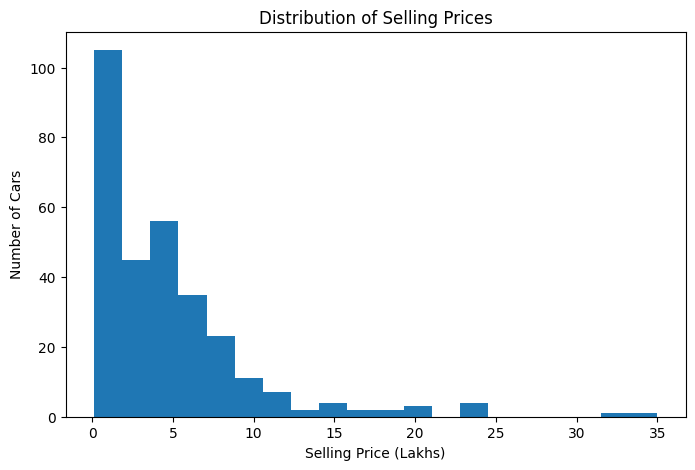

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["Selling_Price"], bins=20)

plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.title("Distribution of Selling Prices")

plt.show()

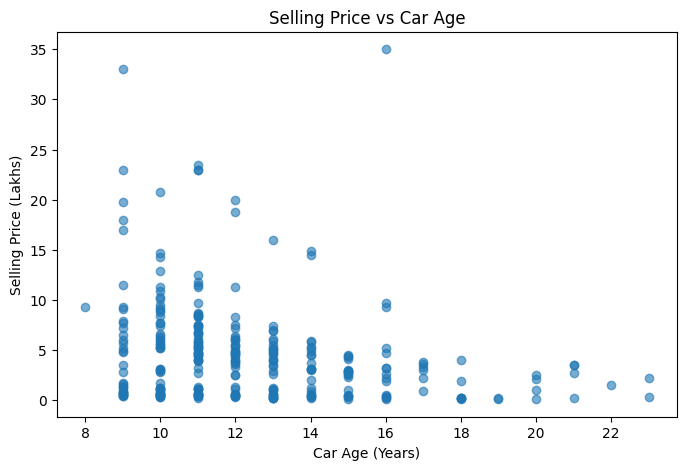

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Car_Age"], df["Selling_Price"], alpha=0.6)

plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")
plt.title("Selling Price vs Car Age")

plt.show()

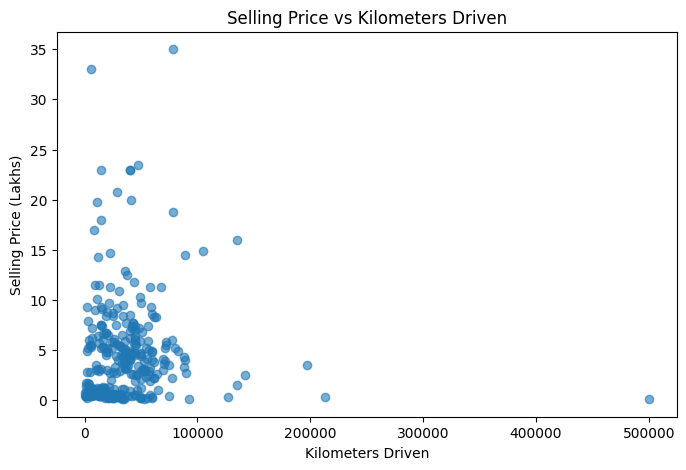

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Kms_Driven"], df["Selling_Price"], alpha=0.6)

plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price (Lakhs)")
plt.title("Selling Price vs Kilometers Driven")

plt.show()

<Figure size 800x500 with 0 Axes>

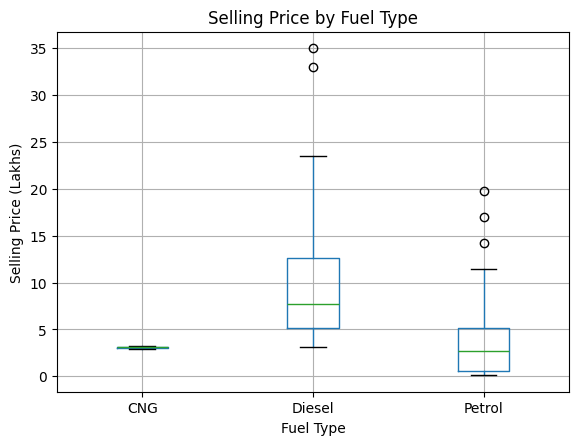

In [19]:
plt.figure(figsize=(8, 5))

df.boxplot(column="Selling_Price", by="Fuel_Type")

plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")
plt.title("Selling Price by Fuel Type")
plt.suptitle("")

plt.show()

<Figure size 800x500 with 0 Axes>

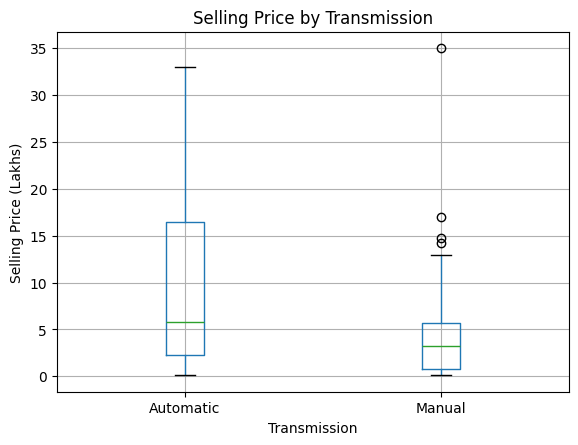

In [20]:
plt.figure(figsize=(8, 5))

df.boxplot(column="Selling_Price", by="Transmission")

plt.xlabel("Transmission")
plt.ylabel("Selling Price (Lakhs)")
plt.title("Selling Price by Transmission")
plt.suptitle("")

plt.show()

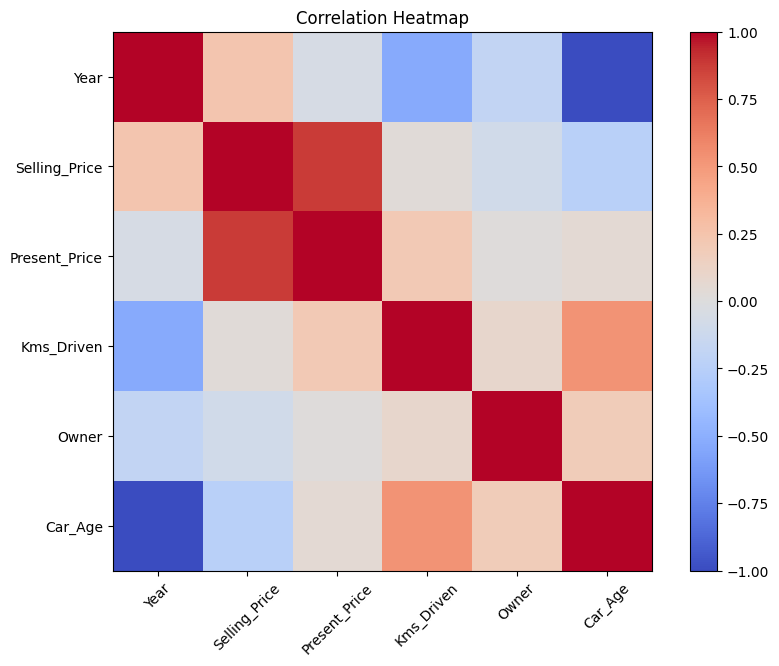

In [21]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

plt.imshow(correlation, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age',
       'Brand'],
      dtype='object')

In [23]:
X = df[
    [
        "Present_Price",
        "Kms_Driven",
        "Fuel_Type",
        "Seller_Type",
        "Transmission",
        "Owner",
        "Car_Age",
        "Brand"
    ]
]

y = df["Selling_Price"]

print("Features and target created successfully!")

Features and target created successfully!


In [24]:
X.head()

,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,6.87,42450,Diesel,Dealer,Manual,0,12,swift


In [25]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [26]:
X_encoded = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True
)

print("Categorical variables encoded successfully!")

Categorical variables encoded successfully!


In [27]:
X_encoded.head()

,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Activa,Brand_Bajaj,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,5.59,27000,0,12,False,True,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,9.54,43000,0,13,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,9.85,6900,0,9,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4.15,5200,0,15,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4,6.87,42450,0,12,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


In [28]:
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (301, 8)
Encoded X shape: (301, 51)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 51)
Testing data: (61, 51)


In [30]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Linear Regression metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

print("\nRandom Forest Regression")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Linear Regression
MAE : 1.2184085862601983
RMSE: 1.8597275852064363
R²  : 0.8498589567748382

Random Forest Regression
MAE : 0.6151803278688528
RMSE: 0.9033472456533581
R²  : 0.9645749711490618


## Model Comparison

Two regression models were evaluated: Linear Regression and Random Forest Regression.

Random Forest performed better than Linear Regression, with a lower MAE and RMSE and a higher R² score. Therefore, Random Forest was selected as the best-performing model for this dataset.

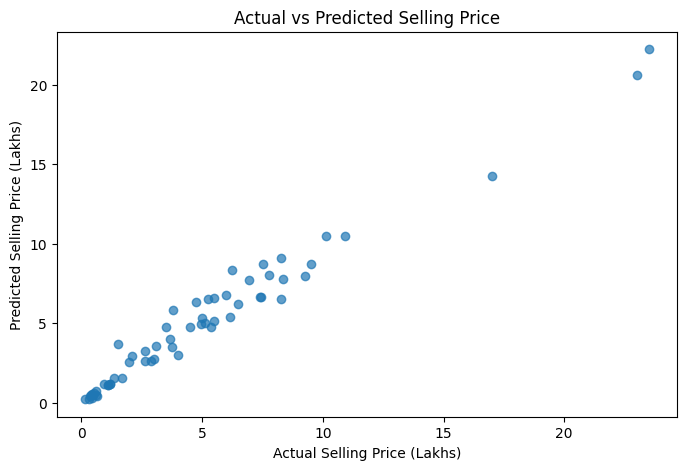

In [33]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.title("Actual vs Predicted Selling Price")

plt.show()

## Actual vs Predicted Prices

The actual and predicted selling prices show a strong positive relationship. Most of the predicted values are close to the actual values, indicating that the Random Forest model performs well on the test data.

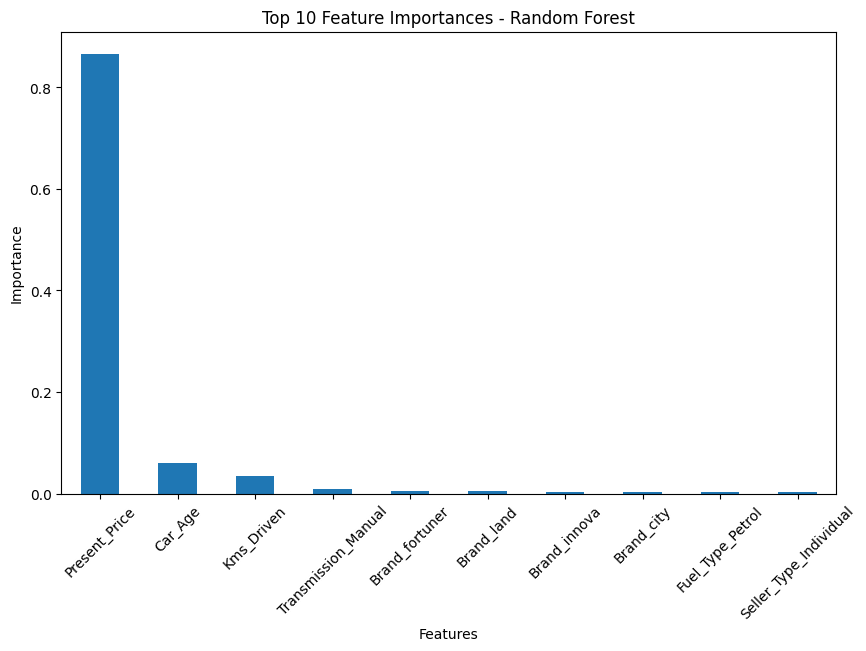

In [39]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_encoded.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))

feature_importance.head(10).plot(kind="bar")

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")

plt.xticks(rotation=45)
plt.show()

## Feature Importance

The feature-importance analysis shows that Present_Price is the most important feature for predicting Selling_Price in the Random Forest model. Car_Age and Kms_Driven also contribute to the predictions, while the categorical features have smaller contributions.

In [40]:
sample_car = X_test.iloc[[0]]

predicted_price = rf_model.predict(sample_car)[0]

print("Predicted Selling Price:", round(predicted_price, 2), "Lakhs")

Predicted Selling Price: 0.44 Lakhs


## Conclusion

In this project, a machine learning model was developed to predict used car selling prices.

The dataset was cleaned and explored using exploratory data analysis. New features such as Car_Age and Brand were created, and categorical variables were encoded for machine learning.

Two regression models were trained:
- Linear Regression
- Random Forest Regression

Random Forest performed better than Linear Regression, with a lower MAE and RMSE and a higher R² score. Therefore, Random Forest was selected as the best-performing model.

The feature-importance analysis showed that Present_Price was the most important feature for predicting Selling_Price.

Overall, the Random Forest model provided strong predictive performance on the test dataset.